## ДОМАШНЕЕ ЗАДАНИЕ

### **Задача:** повторите туториал на датасете **Iris**

**Датасет Iris:**
- 150 примеров цветков ириса
- 3 вида (Setosa, Versicolor, Virginica)
- 4 признака (длина/ширина чашелистика и лепестка)

### **Требования:**
1. **часть 1-2: анализ данных**
   - загрузите датасет `sklearn.datasets.load_iris()`
   - создайте 2 графика распределения классов
   - визуализируйте данные в 2D (выберите 2 любых признака)

2. **часть 3-5: подготовка и обучение**
   - разделите данные 70/30 с `stratify`
   - масштабируйте признаки
   - обучите SVM с линейным ядром

3. **часть 6: эксперименты**
   - попробуйте 3 разных значения C: 0.1, 1, 10
   - сравните accuracy каждой модели
   - выберите лучшую

4. **часть 7-8: оценка**
   - постройте матрицу ошибок для лучшей модели
   - вычислите precision, recall, F1-score
   - найдите и проанализируйте 2 примера ошибок

5. **часть 9: анализ**
   - постройте кривую обучения
   - ответьте: модель переобучается или недообучается?
   - что можно улучшить?

### **Формат сдачи:**
- **Colab ноутбук** с выполненным кодом
- **краткий отчет** (3-5 предложений) с выводами:
  - какая точность достигнута?
  - на каких классах чаще ошибается модель?
  - какие параметры SVM сработали лучше всего?

### **Критерии оценки:**
1. корректная загрузка и анализ данных
2. правильное разделение и масштабирование
3. обучение SVM с разными параметрами (показать, что вы делали как минимум 2 прогона с разными гиперпараметрами, 1 прогон даёт 1 балл)
4. визуализация матрицы ошибок
5. вычисление метрик precision, recall, F1
6. построение кривой обучения
7. представлены ответы на все вопросы из списка требований

### **Дедлайн:** 14 февраля, 23:59 в свои учебные репозитории

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

# импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# загружаем датасет
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"размер данных: {X.shape}")
print(f"количество классов: {len(np.unique(y))}")
print(f"названия классов: {target_names}")
print(f"признаки: {feature_names}")

размер данных: (150, 4)
количество классов: 3
названия классов: ['setosa' 'versicolor' 'virginica']
признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['iris_type'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# первые 5 строк
print(df.head())

# базовая статистика
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target iris_type  
0       0    setosa  
1       0    setosa  
2       0    setosa  
3       0    setosa  
4       0    setosa  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%

/tmp/ipython-input-2268306859.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='iris_type', data=df, palette='Set2')


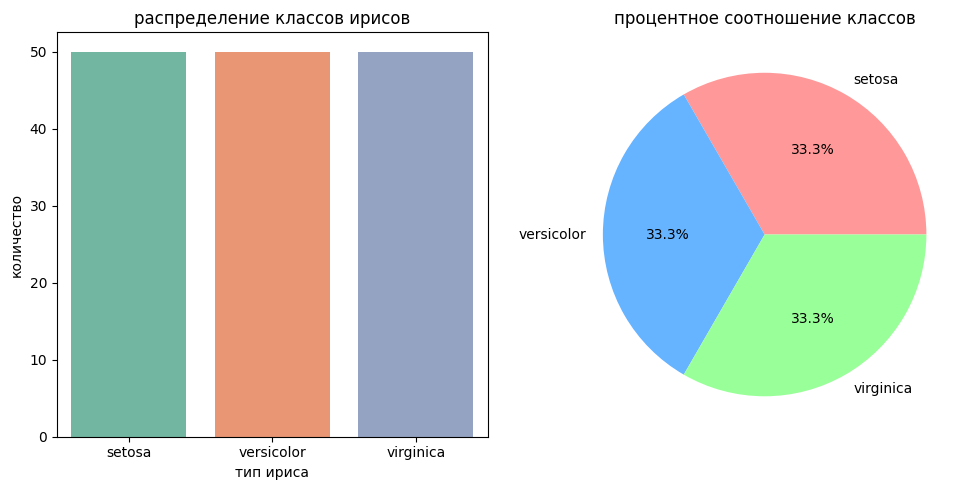

In [ ]:
plt.figure(figsize=(10, 5))

# гистограмма по классам
plt.subplot(1, 2, 1)
sns.countplot(x='iris_type', data=df, palette='Set2')
plt.title('распределение классов ирисов')
plt.xlabel('тип ириса')
plt.ylabel('количество')

# круговая диаграмма
plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('процентное соотношение классов')

plt.tight_layout()
plt.show()

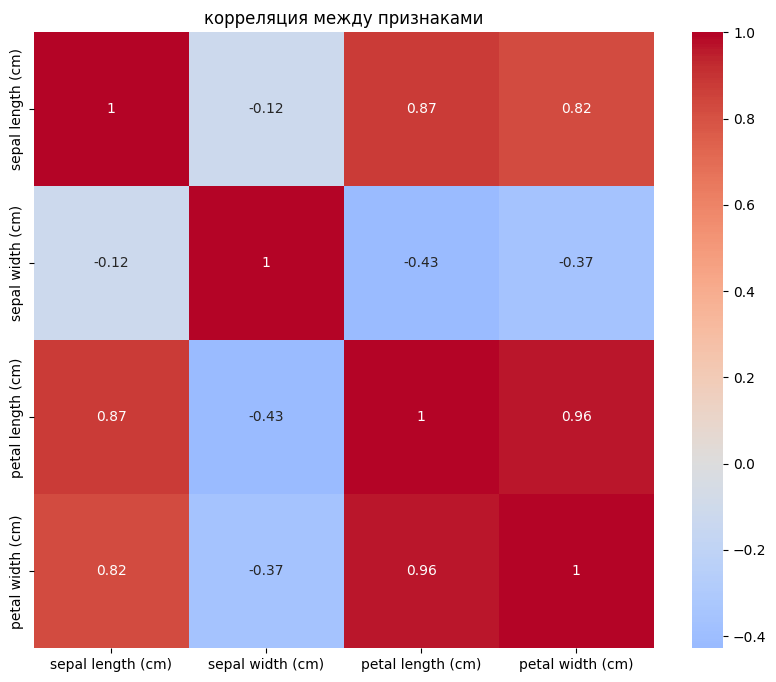

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_names[:6]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('корреляция между признаками')
plt.show()

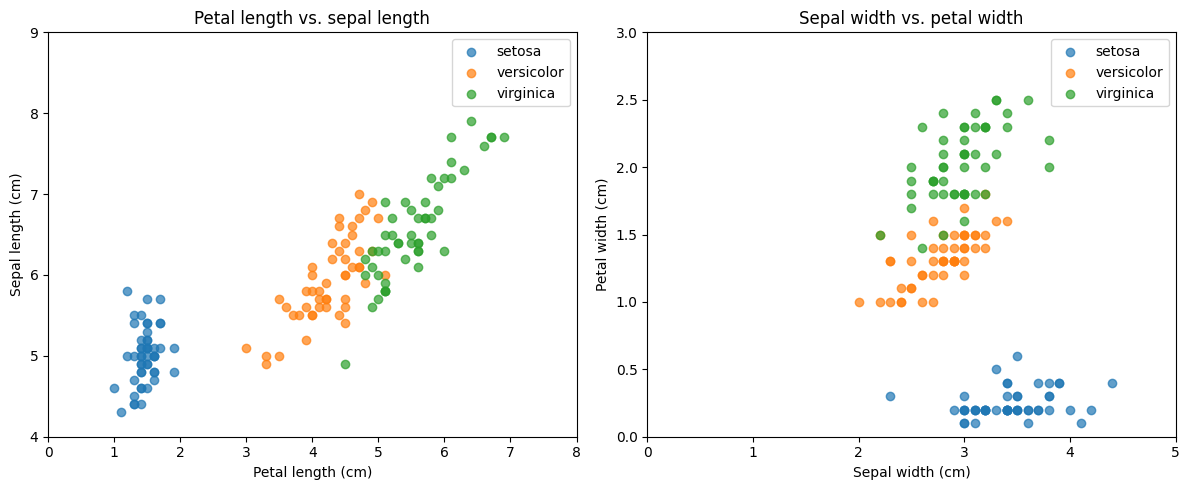

In [ ]:
plt.figure(figsize=(12, 5))

# petal length vs sepal length
plt.subplot(1, 2, 1)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['petal length (cm)'],
                df[df['target'] == i]['sepal length (cm)'],
                label=iris_class, alpha=0.7)
plt.xlabel('Petal length (cm)')
plt.ylabel('Sepal length (cm)')
plt.legend()
plt.title('Petal length vs. sepal length')
plt.ylim(4, 9)
plt.xlim(0, 8)

# sepal width vs. petal_width
plt.subplot(1, 2, 2)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['sepal width (cm)'],
                df[df['target'] == i]['petal width (cm)'],
                label=iris_class, alpha=0.7)
plt.xlabel('Sepal width (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()
plt.title('Sepal width vs. petal width')
plt.ylim(0, 3)
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [27]:
# разделите данные 70/30 с stratify

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

# масштабируйте признаки

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"До масштабирования (пример):\n {X_train[0, :]}")
print(f"После масштабирования (пример): \n {X_train_scaled[0, :]}")

# обучите линейным ядром
svm_linear = SVC(kernel='linear', random_state=42) # C по умолчанию = 1
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"линейный SVM accuracy: {accuracy_linear:.2%}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_linear, target_names=target_names))

Train size: (105, 4)
Test size: (45, 4)
Train class distribution: [35 35 35]
Test class distribution: [15 15 15]
До масштабирования (пример):
 [5.1 2.5 3.  1.1]
После масштабирования (пример): 
 [-0.90045861 -1.22024754 -0.4419858  -0.13661044]
линейный SVM accuracy: 91.11%

classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [35]:
# попробуйте 3 разных значения C: 0.1, 1, 10

# C = 0.1
svm_low = SVC(C=0.1, random_state=42) # по умолчанию kernel='rbf'
svm_low.fit(X_train_scaled, y_train)
y_pred_low = svm_low.predict(X_test_scaled)
accuracy_low = accuracy_score(y_test, y_pred_low)
print(f"RBF SVM accuracy: {accuracy_low:.2%}")

# C = 1
svm_norm = SVC(random_state=42) # по умолчанию kernel='rbf', C=1
svm_norm.fit(X_train_scaled, y_train)
y_pred_norm = svm_norm.predict(X_test_scaled)
accuracy_norm = accuracy_score(y_test, y_pred_norm)
print(f"RBF SVM accuracy: {accuracy_norm:.2%}")


# C = 10
svm_high = SVC(C=10, random_state=42)
svm_high.fit(X_train_scaled, y_train)
y_pred_high = svm_high.predict(X_test_scaled)
accuracy_high = accuracy_score(y_test, y_pred_high)
print(f"RBF SVM accuracy: {accuracy_high:.2%}")

RBF SVM accuracy: 86.67%
RBF SVM accuracy: 93.33%
RBF SVM accuracy: 93.33%


In [36]:
# сравните accuracy каждой модели
# выберите лучшую
# используем найденные лучшие параметры
best_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 93.33%


Модель RBF SVM с С = 1 имеет наибольшую accuracy с наибольшим количеством опорных векторов, поэтому для последующей работы выбираю её

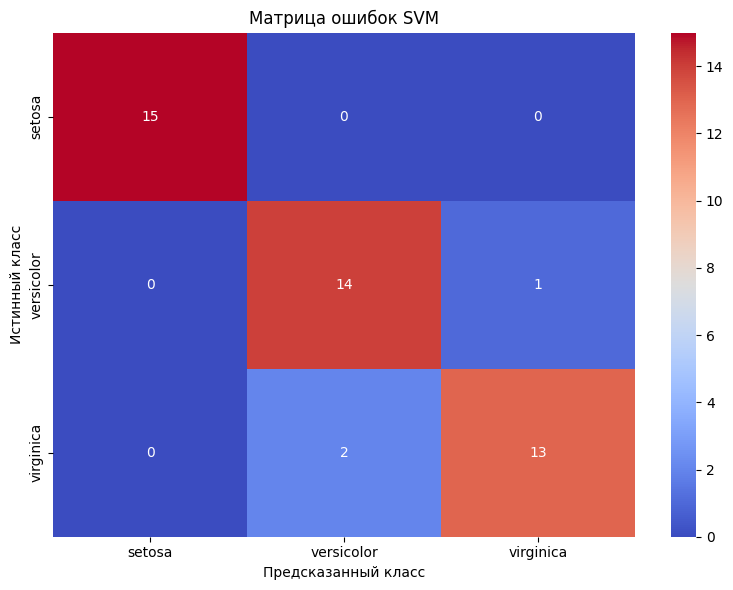

In [38]:
# постройте матрицу ошибок для лучшей модели

cm = confusion_matrix(y_test, y_pred_norm_c)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок SVM')

plt.tight_layout()
plt.show()

In [37]:
# вычислите precision, recall, F1-score
print("детальный отчет по классификации:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

# вычисляем дополнительные метрики вручную
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"\nитоговые метрики:")
print(f"precision: {precision:.2%}  # точность (сколько из предсказанных правильные)")
print(f"recall:    {recall:.2%}    # полнота (сколько из реальных нашли)")
print(f"F1-score:  {f1:.2%}     # баланс precision и recall")

детальный отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


итоговые метрики:
precision: 93.45%  # точность (сколько из предсказанных правильные)
recall:    93.33%    # полнота (сколько из реальных нашли)
F1-score:  93.33%     # баланс precision и recall


In [40]:
# найдите и проанализируйте 2 примера ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nпримеры ошибок:")

    for i, idx in enumerate(error_indices[:3]):  # покажем первые 3
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: {best_svm.decision_function(X_test_scaled[idx:idx+1])}")

количество ошибок: 3

примеры ошибок:

ошибка 1:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.23222733  2.20414076  1.13916713]]

ошибка 2:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.22960759  2.18724266  1.16079295]]

ошибка 3:
  истинный класс: versicolor
  предсказанный:  virginica
  вероятности классов: [[-0.22919805  1.15483972  2.1904854 ]]


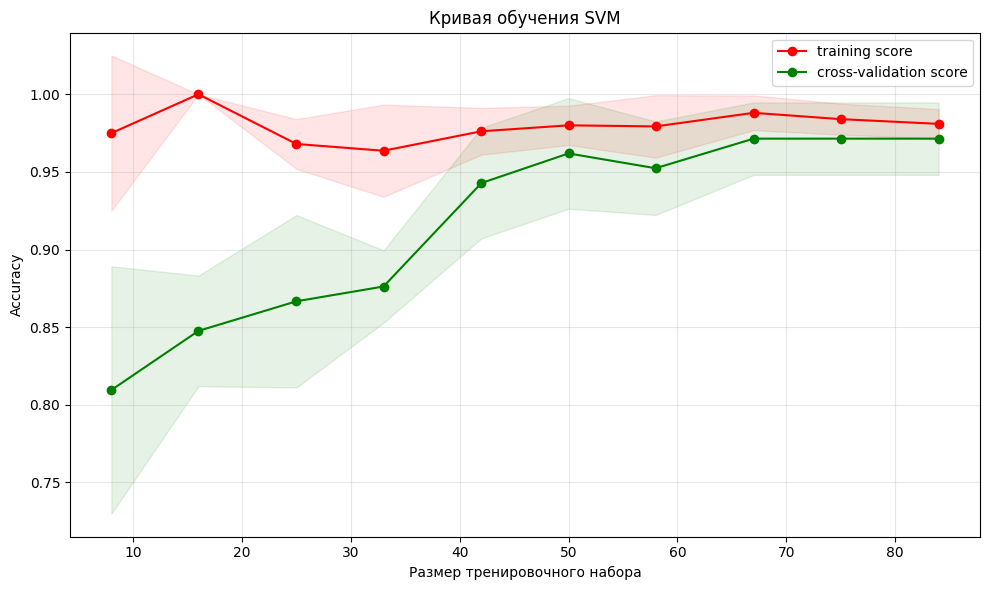

In [41]:
# постройте кривую обучения

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    svm_norm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Размер тренировочного набора')
plt.ylabel('Accuracy')
plt.title('Кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Линии графика в итоге сводятся к высокому значению точности, а это значит, что модель сбалансирована

Что улучшить: увеличить количество данных

Достигнута точность 93%. Модель чаще ошибалась на классе virginica, скорее всего, из-за схожего размера лепестков. Лучше сработали параметры с высоким С